In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up plot styling
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (20, 6)

In [2]:
# Load the data
customers = pd.read_csv('Wholesale_customers_data.csv')
customers['Channel'] = customers['Channel'].astype('category')
customers['Region'] = customers['Region'].astype('category')
customer_features = customers.select_dtypes(include=np.number)

In [5]:
n, p = customer_features.shape[0], customer_features.shape[1]
n, p

(440, 6)

In [3]:
customer_features.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


## Sampling 

We can use the Survey Monkey [Sample Size Calculator](https://www.surveymonkey.com/mp/sample-size-calculator/) to consider what sample sizes we will need for our data to representative of the whole. 

#### Test 1 - `n = 5`

In [6]:
# Calculate original means
sum_vals = pd.DataFrame({'feature': customer_features.columns})
sum_vals['mean_'] = customer_features.mean().values
sum_vals

,feature,mean_
0,Fresh,12000.297727
1,Milk,5796.265909
2,Grocery,7951.277273
3,Frozen,3071.931818
4,Detergents_Paper,2881.493182
5,Delicatessen,1524.870455


In [7]:
# Draw 10 random samples with n=5
samples = []
for i in range(10):
    samples.append(customer_features.sample(n=5))

In [10]:
len(samples)

10

In [9]:
from IPython.display import display
display(samples[0])
display(samples[1])
display(samples[2])

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
221,5396,7503,10646,91,4167,239
92,9198,27472,32034,3232,18906,5130
167,2926,3195,3268,405,1680,693
408,8257,3880,6407,1646,2730,344
391,2647,2761,2313,907,95,1827


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
309,918,20655,13567,1465,6846,806
75,20398,1137,3,4407,3,975
133,9434,1042,1235,436,256,396
22,31276,1917,4469,9408,2381,4334
182,694,8533,10518,443,6907,156


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
409,8708,3634,6100,2349,2123,5137
316,7127,1375,2201,2679,83,1059
288,16260,594,1296,848,445,258
87,43265,5025,8117,6312,1579,14351
37,15168,10556,12477,1920,6506,714


In [11]:
# Calculate means for each sample
for i in range(10):
    sum_vals[f'mean_{i+1}'] = samples[i].mean().values

In [12]:
sum_vals

,feature,mean_,mean_1,mean_2,mean_3,mean_4,mean_5,mean_6,mean_7,mean_8,mean_9,mean_10
0,Fresh,12000.297727,5684.8,12544.0,18105.6,15446.6,9766.6,9221.2,23404.0,22135.4,7267.4,8448.2
1,Milk,5796.265909,8962.2,6656.8,4236.8,6472.0,5382.6,7090.8,4475.4,4484.0,6244.0,7288.8
2,Grocery,7951.277273,10933.6,5958.4,6038.2,8413.6,19688.0,9771.2,7931.6,4480.4,4077.2,9522.8
3,Frozen,3071.931818,1256.2,3231.8,2821.6,4426.2,3163.8,682.4,2213.8,2797.8,2188.6,2728.2
4,Detergents_Paper,2881.493182,5515.6,3278.6,2147.2,3980.2,10147.0,3972.6,1692.4,1531.2,1254.8,4294.0
5,Delicatessen,1524.870455,1646.6,1333.4,4303.8,2670.0,1233.4,1874.0,1626.6,1516.0,1599.8,1328.2


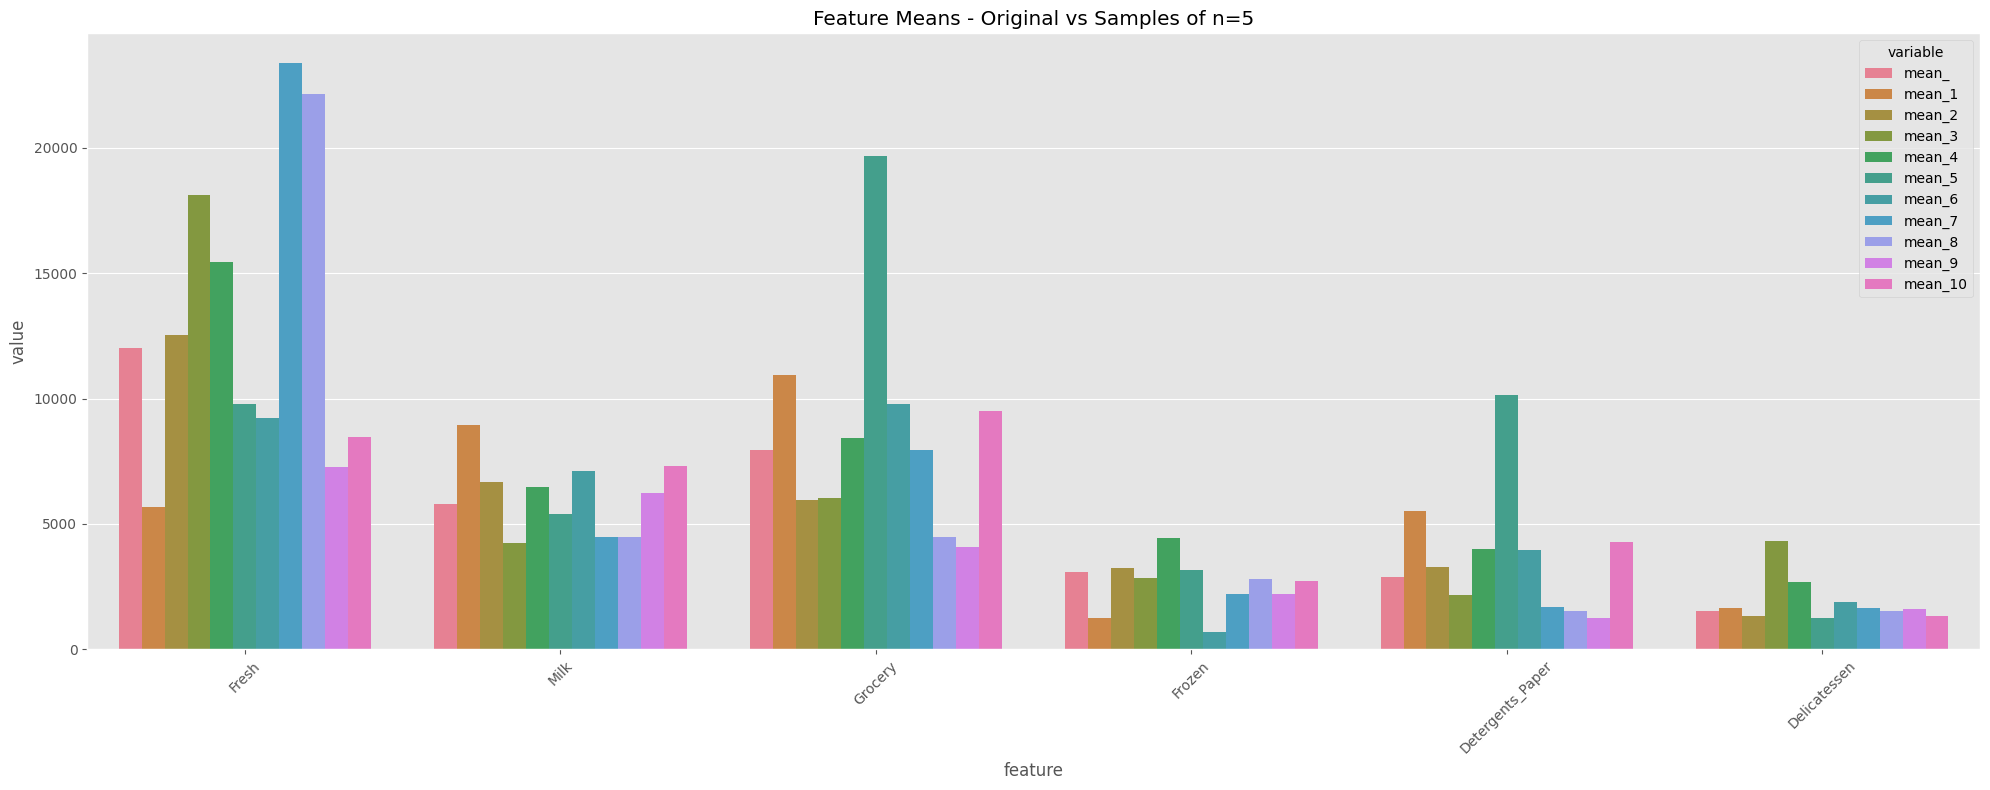

In [13]:
# Melt the dataframe for plotting
melted_sum = pd.melt(sum_vals, id_vars=['feature'])

# Create bar plot
plt.figure(figsize=(20, 8))
sns.barplot(x='feature', y='value', hue='variable', data=melted_sum)
plt.title('Feature Means - Original vs Samples of n=5')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Test 2 - `n = 50`

In [14]:
# Calculate original means again
sum_vals = pd.DataFrame({'feature': customer_features.columns})
sum_vals['mean_'] = customer_features.mean().values
sum_vals

,feature,mean_
0,Fresh,12000.297727
1,Milk,5796.265909
2,Grocery,7951.277273
3,Frozen,3071.931818
4,Detergents_Paper,2881.493182
5,Delicatessen,1524.870455


In [15]:
# Draw 10 random samples with n=50
samples = []
for i in range(10):
    samples.append(customer_features.sample(n=50))

In [16]:
# Calculate means for each sample
for i in range(10):
    sum_vals[f'mean_{i+1}'] = samples[i].mean().values

In [17]:
sum_vals

,feature,mean_,mean_1,mean_2,mean_3,mean_4,mean_5,mean_6,mean_7,mean_8,mean_9,mean_10
0,Fresh,12000.297727,13651.96,15457.34,9171.86,11609.84,11601.30,12491.30,13091.24,13156.74,12467.84,11010.32
1,Milk,5796.265909,4169.22,6241.44,6047.48,7603.36,5464.98,6986.94,4116.56,5300.34,5416.52,4811.78
2,Grocery,7951.277273,6580.34,7515.80,9187.26,10453.56,8091.14,6892.50,6307.08,7874.62,7982.44,9575.58
3,Frozen,3071.931818,2165.32,3551.44,2293.42,2746.24,2369.12,2538.48,2490.74,3247.26,3569.92,2356.64
4,Detergents_Paper,2881.493182,2322.78,2085.86,3603.82,4007.58,2873.06,2594.20,2249.30,2622.68,2881.34,3449.68
5,Delicatessen,1524.870455,1069.54,2115.72,1376.10,2316.86,1275.90,1646.52,1269.40,1741.64,1658.60,1227.68


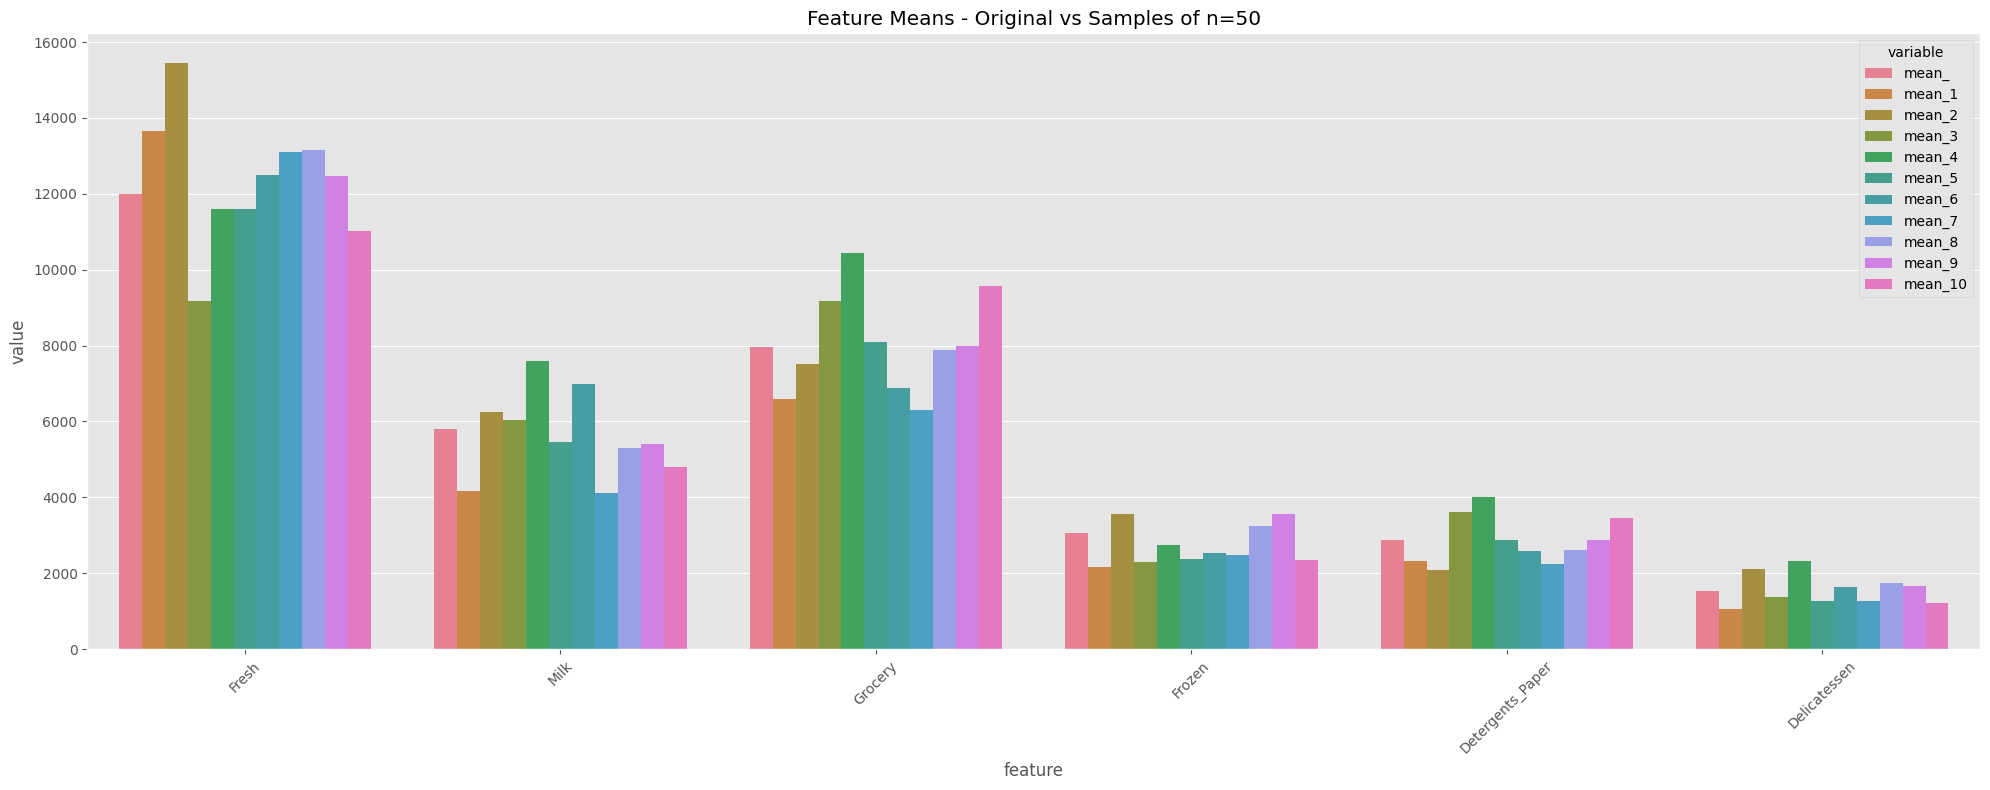

In [18]:
# Melt the dataframe for plotting
melted_sum = pd.melt(sum_vals, id_vars=['feature'])

# Create bar plot
plt.figure(figsize=(20, 8))
sns.barplot(x='feature', y='value', hue='variable', data=melted_sum)
plt.title('Feature Means - Original vs Samples of n=50')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Test 3 - `n = 150`

In [19]:
# Calculate original means again
sum_vals = pd.DataFrame({'feature': customer_features.columns})
sum_vals['mean_'] = customer_features.mean().values
sum_vals

,feature,mean_
0,Fresh,12000.297727
1,Milk,5796.265909
2,Grocery,7951.277273
3,Frozen,3071.931818
4,Detergents_Paper,2881.493182
5,Delicatessen,1524.870455


In [20]:
# Draw 10 random samples with n=150
samples = []
for i in range(10):
    samples.append(customer_features.sample(n=150))

In [21]:
# Calculate means for each sample
for i in range(10):
    sum_vals[f'mean_{i+1}'] = samples[i].mean().values

In [22]:
sum_vals

,feature,mean_,mean_1,mean_2,mean_3,mean_4,mean_5,mean_6,mean_7,mean_8,mean_9,mean_10
0,Fresh,12000.297727,12366.753333,11300.413333,13330.280000,10954.473333,11943.986667,11681.613333,13565.626667,12900.673333,12563.113333,10769.326667
1,Milk,5796.265909,5714.820000,5267.733333,6212.666667,6354.686667,5108.313333,5622.513333,5257.033333,5416.013333,5515.246667,4860.713333
2,Grocery,7951.277273,7867.033333,6874.946667,7460.746667,8168.586667,7140.360000,7430.540000,7536.973333,8009.533333,7890.600000,7461.366667
3,Frozen,3071.931818,2963.740000,3370.453333,3746.280000,3090.873333,3390.713333,3523.773333,3142.666667,3184.980000,3094.806667,2477.026667
4,Detergents_Paper,2881.493182,2767.033333,2387.433333,2458.633333,2963.753333,2356.980000,2682.420000,2569.040000,2886.286667,2790.120000,2468.020000
5,Delicatessen,1524.870455,1622.653333,1307.506667,1824.646667,1634.986667,1429.393333,1527.540000,1464.080000,1623.040000,1388.020000,1230.653333


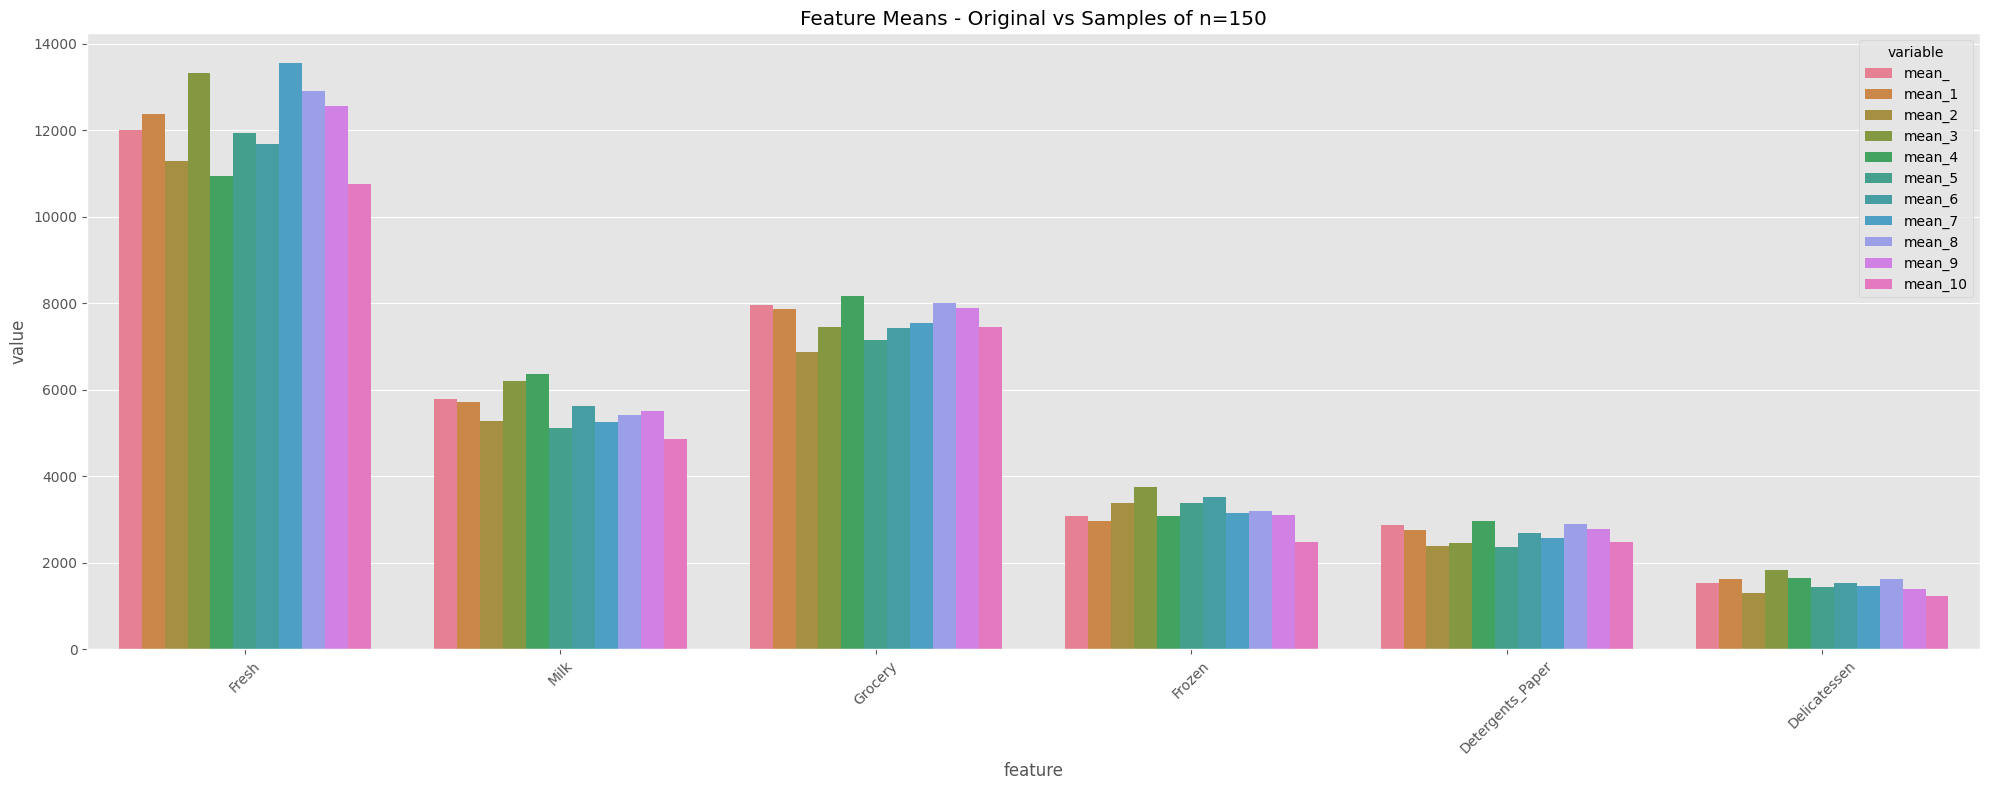

In [23]:
# Melt the dataframe for plotting
melted_sum = pd.melt(sum_vals, id_vars=['feature'])

# Create bar plot
plt.figure(figsize=(20, 8))
sns.barplot(x='feature', y='value', hue='variable', data=melted_sum)
plt.title('Feature Means - Original vs Samples of n=150')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()